In [ ]:
%matplotlib inline

# Training a Classifier



In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

from torch.utils.tensorboard import SummaryWriter
from torch import nn

The output of torchvision datasets are PILImage images of range \[0,
1\]. We transform them to Tensors of normalized range \[-1, 1\].


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>If you are running this tutorial on Windows or MacOS and encounter aBrokenPipeError or RuntimeError related to multiprocessing, try settingthe num_worker of torch.utils.data.DataLoader() to 0.</p>

</div>



## Default device

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# Assuming that we are on a CUDA machine, this should print a CUDA device:
print(device)

## Prepare data

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


# Common Functions

## Show Image

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

## Test accuracy

Cheatsheet

```
:param int arg1: Description of arg1.
:param str arg2: Description of arg2.
:return: Description of return value
:rtype: bool
:raises ValueError: if arg1 is equal to arg2
```

In [ ]:
def is_exact_match(pred_tensor: torch.Tensor, y: int):
    """Default comparison. Whether a classification vector is exact match or not.

    :param torch.Tensor pred_tensor: Prediction vector of size n.
    :param int y: True class out of [0, n].
    :return: True if exact match, False if not.
    :rtype: bool
    """
    if pred_tensor.dim() == 0:
        return False
    _, pred_y = torch.topk(pred_tensor, 1)
    return pred_y == y

In [ ]:
def print_accuracy_on_test(net,
                           is_correct_fn=is_exact_match,
                           testloader=testloader):
    """Print overall accuracy of network on all test data.

    :param nn.Module net:
    :param Callable[[torch.Tensor, int], bool] is_correct_fn: Function defining what is considered correct.
    """
    this_device = next(net.parameters())[0].device
    correct = 0
    total = 0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(this_device), data[1].to(this_device)
            # calculate outputs by running images through the network
            outputs = net(images)
            # the class with the highest energy is what we choose as prediction
            for label, output in zip(labels, outputs):
                if is_correct_fn(output, label):
                    correct += 1
                total += 1

    print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')


def print_accuracy_per_class(net,
                             is_correct_fn=is_exact_match,
                             testloader=testloader,
                             classes=classes):
    """Print accuracy of network on all test data. Accuracy is calculated per class.

    :param nn.Module net:
    :param Callable[[torch.Tensor, int], bool] is_correct_fn: Function defining what is considered correct.
    """
    this_device = next(net.parameters())[0].device

    # prepare to count predictions for each class
    correct_pred = {classname: 0 for classname in classes}
    total_pred = {classname: 0 for classname in classes}

    # again no gradients needed
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(this_device), data[1].to(this_device)
            outputs = net(images)
            # collect the correct predictions for each class
            for label, output in zip(labels, outputs):
                if is_correct_fn(output, label):
                    correct_pred[classes[label]] += 1
                total_pred[classes[label]] += 1

    # print accuracy for each class
    for classname, correct_count in correct_pred.items():
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

## Train network [Task 4]

In [ ]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter("logs/assignment_cnn")

def train_network(net: nn.Module, optimizer, criterion) -> None:
    """Train network on all train data as defined above.

    :param net:
    :param optimizer:
    :param criterion:
    """
    this_device = next(net.parameters()).device
    global_step = 0
    for epoch in range(2):  # loop over the dataset multiple times

        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data
            inputs = inputs.to(this_device)
            labels = labels.to(this_device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            writer.add_scalar("Loss/train", loss.item(), global_step)
            global_step += 1

            if i % 2000 == 1999:    # print every 2000 mini-batches
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f} ({datetime.now()})')
                running_loss = 0.0
    print('Finished Training')

# [Task 1] Train the same network as in the PyTorch CNN tutorial.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class ExampleNet(nn.Module):
    """CNN from tutorial"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
import torch.optim as optim

from datetime import datetime
from models import load_weights, save_weights

# loss_fn: Cross-Entropy
# optimizer: SGD with momentum

EXAMPLE_WEIGHTS = f'./models/cifar_net.pth'

example_net = ExampleNet().to(device)
example_criterion = nn.CrossEntropyLoss()
example_optimizer = optim.SGD(example_net.parameters(), lr=0.001, momentum=0.9)

if load_weights(example_net, EXAMPLE_WEIGHTS):
    print("Loaded weights successfully")
else:
    train_network(net=example_net, criterion=example_criterion, optimizer=example_optimizer)
    save_weights(example_net, EXAMPLE_WEIGHTS)

### Test the network on the test data

In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

#### Test small sample

In [ ]:
outputs = example_net(images.to(device))

In [ ]:
_, predicted = torch.max(outputs, 1)
print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))

Results: 2 out of 4 correct.

### Accuracy on full test set

In [ ]:
print_accuracy_on_test(example_net)

### Accuracy on individual classes

In [ ]:
print_accuracy_per_class(example_net)

In [ ]:
del dataiter

# [Task 2] Change now the network architecture as follows and train the network

In [ ]:
class AssignmentCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Convolution Layer 3x3 depth = 8
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3)

        # Convolution layer 3x3, depth = 16
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3)

        # Max pool 2x2
        self.pool = nn.MaxPool2d(2, 2)

        # Conv layer 3x3, depth 32
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)

        # Convolution Layer 3x3, depth = 64
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)

        self.fc1 = nn.Linear(64 * 5 * 5, 4096)
        self.fc2 = nn.Linear(4096, 1000)
        self.fc3 = nn.Linear(1000, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)


        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [ ]:
net = AssignmentCNN().to(device)
#https://docs.pytorch.org/docs/stable/tensorboard.html
#
images, labels = next(iter(trainloader))
images = images.to(device)
writer.add_graph(net, images)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

if not load_weights(net) or True:
    train_network(net, criterion=criterion, optimizer=optimizer)
    save_weights(net)


In [ ]:
print_accuracy_on_test(net)
print_accuracy_per_class(net)

# [Task 3] Compare CPU vs GPU

CPU: 17m 57s

GPU: 2m 44s

In [ ]:
# cpu_train_net = AssignmentCNN().to('cpu')
# train_network(cpu_train_net,
#     criterion=nn.CrossEntropyLoss(),
#     optimizer=optim.SGD(cpu_train_net.parameters(), lr=0.001, momentum=0.9))

```py
# CPU
cpu_train_net = AssignmentCNN().to('cpu')
train_network(cpu_train_net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(cpu_train_net.parameters(), lr=0.001, momentum=0.9))
```

`<broken image attachment>`

```py
# GPU
gpu_train_net = AssignmentCNN().to('cuda:0')
train_network(gpu_train_net,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.SGD(gpu_train_net.parameters(), lr=0.001, momentum=0.9))
```
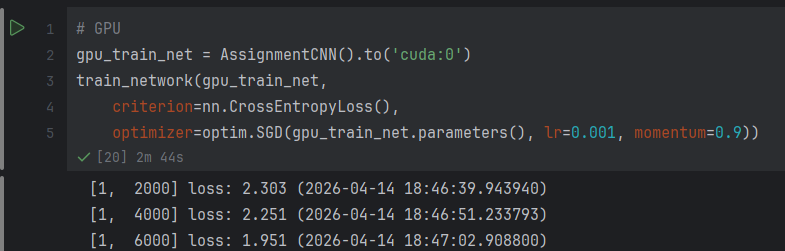

# [Task 4] Log the training loss in tensorboard and also the graph of the network
See Common Functions

# [Task 5] Change the test metric ...

In [ ]:
def is_in_top_three(pred_tensor, target_label):
    _, top3_pred_y = torch.topk(pred_tensor, 3)
    return target_label in top3_pred_y

In [ ]:
def test():
    t = torch.randn(10)
    print(f'input=\n{t}\ntop3=\n{torch.topk(t, 3)}\nfn={is_in_top_three(t, 3)}\n')
test()
test()

In [ ]:
print_accuracy_on_test(net, is_correct_fn=is_in_top_three)
print_accuracy_on_test(example_net, is_correct_fn=is_in_top_three)

In [ ]:
print_accuracy_per_class(net, is_correct_fn=is_in_top_three)
print('\n\n')
print_accuracy_per_class(example_net, is_correct_fn=is_in_top_three)

# [Task 6] Randomly take 5 examples on which the network was wrong

In [ ]:
import random
import torchvision
import matplotlib.pyplot as plt
import numpy as np


def unnormalize(img):
    return img * 0.5 + 0.5


def log_five_wrong_top3_examples(net, testloader, writer, classes):
    net.eval()
    this_device = next(net.parameters()).device
    wrong_examples = []

    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(this_device)
            labels = labels.to(this_device)

            outputs = net(images)

            for i in range(len(images)):
                output_i = outputs[i]
                label_i = labels[i]

                if not is_in_top_three(output_i, label_i):
                    _, top3_idx = torch.topk(output_i, 3)

                    wrong_examples.append({
                        "image": images[i].cpu(),
                        "true_label": label_i.cpu().item(),
                        "top1_pred": top3_idx[0].cpu().item(),
                        "top3_pred": top3_idx.cpu().tolist()
                    })

    if len(wrong_examples) == 0:
        print("Keine falsch klassifizierten Beispiele gefunden.")
        return

    selected = random.sample(wrong_examples, min(5, len(wrong_examples)))

    for i, ex in enumerate(selected):
        img = unnormalize(ex["image"])

        true_label_name = classes[ex["true_label"]]
        top1_pred_name = classes[ex["top1_pred"]]
        top3_pred_names = [classes[idx] for idx in ex["top3_pred"]]


        npimg = img.numpy()
        npimg = np.transpose(npimg, (1, 2, 0))

        fig, ax = plt.subplots()
        ax.imshow(npimg)
        ax.set_title(
            f"true: {true_label_name}\npred: {top1_pred_name}\ntop3: {top3_pred_names}"
        )
        ax.axis("off")

        writer.add_figure(f"wrong_top3/example_{i}", fig)
        plt.close(fig)

        print(f"Example {i}: true={true_label_name}, pred={top1_pred_name}, top3={top3_pred_names}")

In [ ]:
log_five_wrong_top3_examples(net, testloader, writer, classes)

 **Clean up**

In [ ]:
writer.close()

# [Task 7] Show the tensor board widget at the end of your notebook

In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs